# Kazan Temporal Normative Review

Ноутбук для визуального сравнения `Observed`, `Reconstructed` и `Temporal Normative` по выборке `Казань + Выпечка сытная + 30 пекарен`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed"

RECON_PATH = DATA_DIR / "kazan_reconstructed_sku_day.csv"
TEMPORAL_PATH = DATA_DIR / "kazan_temporal_normative_sku_day.csv"
PATH_SCORES_PATH = DATA_DIR / "kazan_decomposition_path_scores.csv"

RECON_PATH, TEMPORAL_PATH

(WindowsPath('c:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/kazan_reconstructed_sku_day.csv'),
 WindowsPath('c:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/kazan_temporal_normative_sku_day.csv'))

In [2]:
recon = pd.read_csv(RECON_PATH, encoding="utf-8-sig", low_memory=False)
temporal = pd.read_csv(TEMPORAL_PATH, encoding="utf-8-sig", low_memory=False)
path_scores = pd.read_csv(PATH_SCORES_PATH, encoding="utf-8-sig", low_memory=False)

for df in [recon, temporal]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

temporal.shape

(231695, 43)

## 1. Сводка по temporal layer


In [3]:
summary = {
    "rows": len(temporal),
    "dates": temporal["date"].nunique(),
    "bakeries": temporal["bakery_id"].nunique(),
    "sku": temporal["product_id"].nunique(),
    "mean_observed": temporal["observed_sales_qty"].mean(),
    "mean_reconstructed": temporal["reconstructed_sales_qty"].mean(),
    "mean_temporal_normative": temporal["temporal_normative_qty"].mean(),
    "mean_temporal_abs_gap": temporal["temporal_normative_abs_gap"].mean(),
    "mean_temporal_bias": temporal["temporal_normative_bias"].mean(),
}
pd.Series(summary)

rows                       231695.000000
dates                         481.000000
bakeries                       30.000000
sku                            29.000000
mean_observed                  38.170900
mean_reconstructed             38.109798
mean_temporal_normative        37.334309
mean_temporal_abs_gap           8.200565
mean_temporal_bias             -0.836591
dtype: float64

In [4]:
path_summary = (
    temporal.groupby("best_decomposition_path", dropna=False)
    .agg(
        rows=("best_decomposition_path", "size"),
        mean_observed=("observed_sales_qty", "mean"),
        mean_reconstructed=("reconstructed_sales_qty", "mean"),
        mean_temporal_normative=("temporal_normative_qty", "mean"),
        mean_temporal_abs_gap=("temporal_normative_abs_gap", "mean"),
        mean_temporal_bias=("temporal_normative_bias", "mean"),
    )
    .sort_values("rows", ascending=False)
)
path_summary

,rows,mean_observed,mean_reconstructed,mean_temporal_normative,mean_temporal_abs_gap,mean_temporal_bias
best_decomposition_path,,,,,,
bakery_category_to_sku_cluster_to_sku,149705,47.111171,47.110681,46.348943,9.532275,-0.762227
bakery_total_to_category_to_sku_cluster_to_sku,53511,16.890757,16.589575,15.682428,5.325254,-1.208329
city_sku_to_bakery,18356,34.302471,34.382218,33.839548,6.670675,-0.462922
bakery_cluster_sku_to_bakery,10072,25.551175,25.606302,24.904455,6.495857,-0.646720
NaN,51,7.450980,7.718746,6.378839,3.292584,-1.072142


## 2. Индекс пар `bakery x sku`


In [5]:
pair_index = (
    temporal.groupby([
        "bakery_id", "bakery_name", "product_id", "product_name", "best_decomposition_path"
    ], as_index=False)
    .agg(
        mean_observed=("observed_sales_qty", "mean"),
        mean_reconstructed=("reconstructed_sales_qty", "mean"),
        mean_temporal_normative=("temporal_normative_qty", "mean"),
        mean_temporal_abs_gap=("temporal_normative_abs_gap", "mean"),
        mean_temporal_bias=("temporal_normative_bias", "mean"),
    )
    .sort_values(["mean_observed", "mean_temporal_abs_gap"], ascending=[False, True])
)
pair_index.head(25)

,bakery_id,bakery_name,product_id,product_name,best_decomposition_path,mean_observed,mean_reconstructed,mean_temporal_normative,mean_temporal_abs_gap,mean_temporal_bias
509,142,Баки Урманче 6 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,210.317597,209.065777,207.182505,29.243065,-3.135091
56,16,Кулагина 4 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,200.185852,202.118679,198.656593,30.518996,-1.529260
30,14,Ямашева 19А Казань,1071,Треугольник курица безд,city_sku_to_bakery,180.143451,180.939394,178.712454,23.048948,-1.430997
107,21,Парковая 7 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,172.688150,173.143307,171.014043,22.105432,-1.674106
484,137,Татарстан 53А Казань,1071,Треугольник курица безд,city_sku_to_bakery,166.195426,166.788679,164.735901,28.608174,-1.459525
392,89,Парина 6 Казань,10340,Кыстыбый П,bakery_category_to_sku_cluster_to_sku,165.226611,162.954005,160.386098,28.613956,-4.840513
408,102,Татарстан 16 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,158.137214,158.501746,156.336323,22.698585,-1.800891
459,107,Четаева 46А Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,150.257796,151.051912,148.253870,27.100886,-2.003926
81,19,Хади Такташ 73 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,144.920998,144.741440,142.926132,23.260470,-1.994866
5,12,Восстания 117 Казань,1071,Треугольник курица безд,bakery_category_to_sku_cluster_to_sku,142.692308,144.165027,142.355745,23.030754,-0.336562


In [19]:
pair_index['product_id'].unique()

array([ 1071, 10340,    34,  1076,    57, 10346, 10760, 10667, 10347,
          36,    61, 10556,    42,  4629,  1844,  4241, 10298,    64,
        4944, 10656, 10658, 10608, 11300,  1845, 11305, 10093])

## 3. Выбор конкретной пары


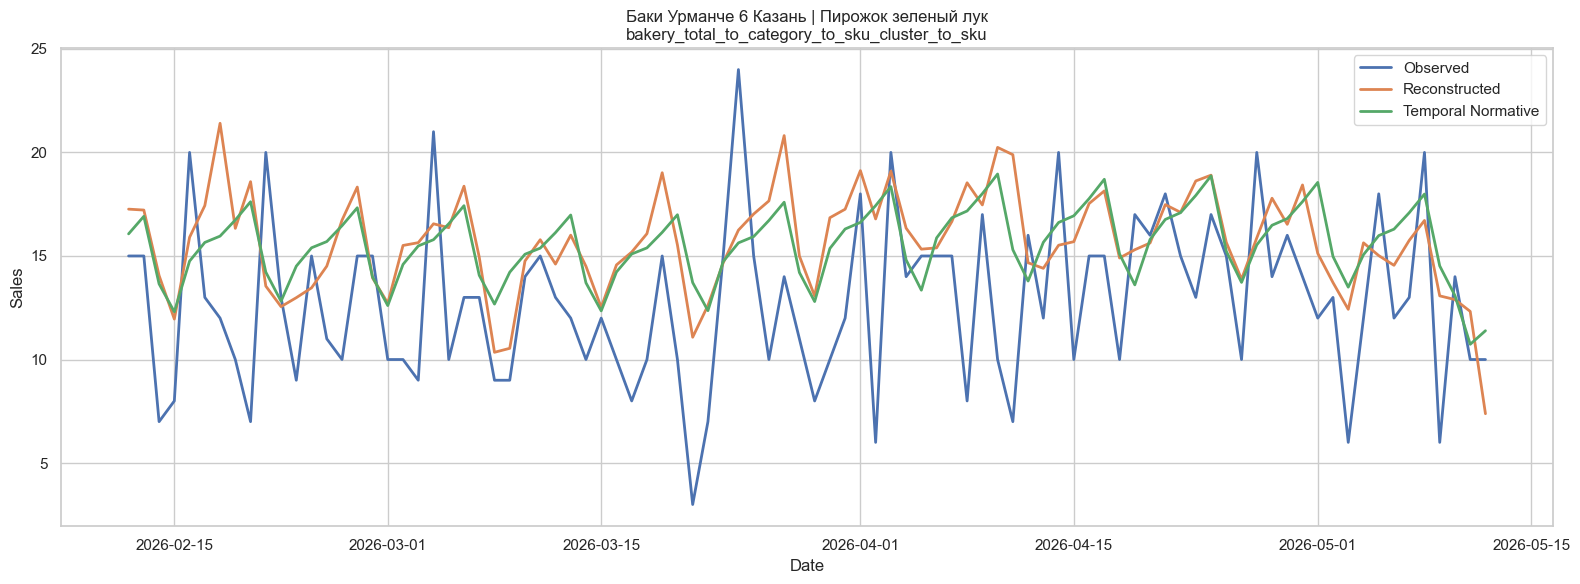

In [32]:
BAKERY_ID = 142
PRODUCT_ID = 42

pair = temporal[
    (temporal["bakery_id"].astype(str) == str(BAKERY_ID))
    & (temporal["product_id"].astype(str) == str(PRODUCT_ID))
].copy().sort_values("date")

pair[[
    "bakery_id", "bakery_name", "product_id", "product_name", "best_decomposition_path"
]].drop_duplicates()
pair_tail = pair.tail(90)
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(pair_tail["date"], pair_tail["observed_sales_qty"], label="Observed", linewidth=2)
ax.plot(pair_tail["date"], pair_tail["reconstructed_sales_qty"], label="Reconstructed", linewidth=2)
ax.plot(pair_tail["date"], pair_tail["temporal_normative_qty"], label="Temporal Normative", linewidth=2)
ax.set_title(
    f"{pair_tail['bakery_name'].iloc[0]} | {pair_tail['product_name'].iloc[0]}\n{pair_tail['best_decomposition_path'].iloc[0]}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()

In [ ]:
pair[[
    "date",
    "observed_sales_qty",
    "reconstructed_sales_qty",
    "temporal_normative_qty",
    "weekly_amplitude_factor",
    "temporal_normative_bias",
]].tail(25)

## 4. Сравнение ошибок: reconstructed vs temporal normative


In [ ]:
compare = temporal.groupby("best_decomposition_path", dropna=False).agg(
    reconstructed_abs_gap=("reconstruction_abs_gap", "mean"),
    reconstructed_bias=("reconstruction_bias", "mean"),
    temporal_abs_gap=("temporal_normative_abs_gap", "mean"),
    temporal_bias=("temporal_normative_bias", "mean"),
).sort_values("temporal_abs_gap")
compare

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=temporal, x="best_decomposition_path", y="reconstruction_abs_gap", ax=axes[0])
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Reconstructed Absolute Gap")

sns.boxplot(data=temporal, x="best_decomposition_path", y="temporal_normative_abs_gap", ax=axes[1])
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("Temporal Normative Absolute Gap")
plt.tight_layout()

## 5. Лучшие и худшие пары по temporal gap


In [ ]:
pair_gap = (
    temporal.groupby([
        "bakery_id", "bakery_name", "product_id", "product_name", "best_decomposition_path"
    ], as_index=False)
    .agg(
        mean_observed=("observed_sales_qty", "mean"),
        mean_temporal_normative=("temporal_normative_qty", "mean"),
        mean_temporal_abs_gap=("temporal_normative_abs_gap", "mean"),
        mean_temporal_bias=("temporal_normative_bias", "mean"),
    )
)
pair_gap["temporal_gap_ratio"] = pair_gap["mean_temporal_abs_gap"] / pair_gap["mean_observed"].replace(0, pd.NA)

print("Best temporal pairs")
display(pair_gap.sort_values(["temporal_gap_ratio", "mean_observed"], ascending=[True, False]).head(20))

print("Worst temporal pairs")
display(pair_gap.sort_values(["temporal_gap_ratio", "mean_observed"], ascending=[False, False]).head(20))

## 6. Быстрый helper для интерактивного просмотра


In [ ]:
def plot_pair(bakery_id: str | int, product_id: str | int) -> pd.DataFrame:
    pair = temporal[
        (temporal["bakery_id"].astype(str) == str(bakery_id))
        & (temporal["product_id"].astype(str) == str(product_id))
    ].copy().sort_values("date")
    if pair.empty:
        print("Pair not found")
        return pair

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(pair["date"], pair["observed_sales_qty"], label="Observed", linewidth=2)
    ax.plot(pair["date"], pair["reconstructed_sales_qty"], label="Reconstructed", linewidth=2)
    ax.plot(pair["date"], pair["temporal_normative_qty"], label="Temporal Normative", linewidth=2)
    ax.set_title(
        f"{pair['bakery_name'].iloc[0]} | {pair['product_name'].iloc[0]}\n{pair['best_decomposition_path'].iloc[0]}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()
    return pair


plot_pair(14, 1071);